# Features Generation Cost Estimation

In [1]:
import os
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

In [2]:
script_path = os.getcwd()
project_path = os.path.join(script_path, '..')
generation_cost_dir = os.path.join(project_path, 'data', 'generation_cost')
total_cost_file_path = os.path.join(generation_cost_dir, 'total_cost.csv')

In [3]:
total_cost_df = pl.read_csv(total_cost_file_path)
total_cost_df

llm_model_name,embedding_model_name,n1,fil_prop,n2,total_cost
str,str,i64,f64,f64,f64
"""gpt-4o""","""text-embedding-3-small""",10000,0.9,9000.0,179.573
"""gpt-4o-mini""","""text-embedding-3-small""",10000,0.9,9000.0,10.799
"""gpt-4o""","""text-embedding-3-small""",10000,0.8,8000.0,162.766
"""gpt-4o-mini""","""text-embedding-3-small""",10000,0.8,8000.0,9.788
"""gpt-4o""","""text-embedding-3-small""",10000,0.7,7000.0,145.959
…,…,…,…,…,…
"""gpt-4o-mini""","""text-embedding-3-small""",70000,0.8,56000.0,68.516
"""gpt-4o""","""text-embedding-3-small""",70000,0.7,49000.0,1021.713
"""gpt-4o-mini""","""text-embedding-3-small""",70000,0.7,49000.0,61.439


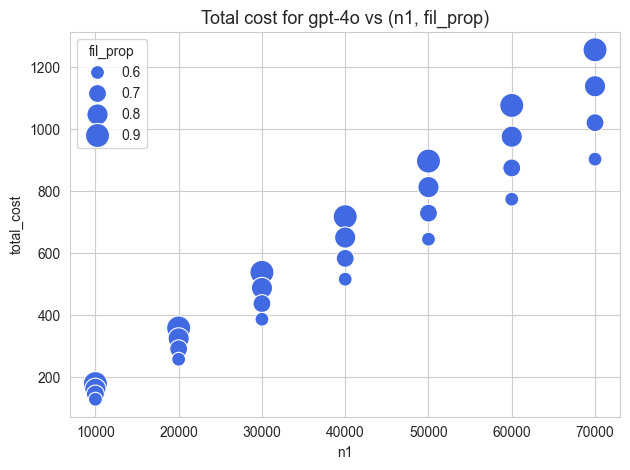

In [6]:
llm_model_name = "gpt-4o"

sns.scatterplot(
    data=total_cost_df.filter(pl.col('llm_model_name') == llm_model_name),
    x="n1",
    y="total_cost",
    size="fil_prop",
    sizes=(100, 300), 
    color='royalblue'
)

plt.xlabel("n1")
plt.ylabel("total_cost")
plt.title(f"Total cost for {llm_model_name} vs (n1, fil_prop)", fontsize=13)

plt.tight_layout()
plt.show()


LLM model: gpt-4o

- Least costly scenario: 100$ (n1=10000, fil_prop=0.6)
- Middle costly scenario: 590$ (n1=40000, fil_prop=0.7)
- Most costly scenario: 1250$ (n1=70000, fil_prop=0.9)
- Realistic scenario (n1=30000-40000, fil_prop=0.6-0.7): 400$-750$

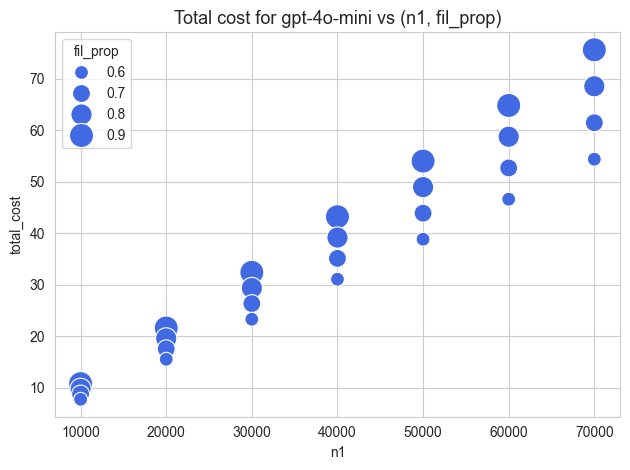

In [7]:
llm_model_name = "gpt-4o-mini"

sns.scatterplot(
    data=total_cost_df.filter(pl.col('llm_model_name') == llm_model_name),
    x="n1",
    y="total_cost",
    size="fil_prop",
    sizes=(100, 300), 
    color='royalblue'
)

plt.xlabel("n1")
plt.ylabel("total_cost")
plt.title(f"Total cost for {llm_model_name} vs (n1, fil_prop)", fontsize=13)

plt.tight_layout()
plt.show()


LLM model: gpt-4o-mini

- Least costly scenario: 5$ (n1=10000, fil_prop=0.6)
- Middle costly scenario: 40$ (n1=40000, fil_prop=0.9)
- Most costly scenario: 77$ (n1=70000, fil_prop=0.8)
- Realistic scenario (n1=30000-40000, fil_prop=0.6-0.7): 23$-35$

**Conclusion:** 

- gpt-4o-mini is a very affordable option, since cost will not exceed 80$ even in big data scenarios. 